# Static POD models for NOAA data

Datasets:

1. NOAA: Weekly mean sea-surface temperature at 1° resolution, as given by the NOAA Optimum Interpolation SST V2 dataset [[1]](https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html)

    - specifically, using the version taken from the Williams et al. pyshred implementation [[2]](https://github.com/Jan-Williams/pyshred/blob/main/Data/SST_data.mat).

2. OFAM3: ME4OH full-field dataset at 1/4° resolution generated from the OFAM3 numerical model [[3]](https://data.csiro.au/collection/csiro%3A60826v9).

Models:
- gappy POD: Partially adapted from qr_place in [[4]](https://github.com/Jan-Williams/pyshred/blob/main/processdata.py)
- RBF Interpolation: using scipy implementation

In [ ]:
# Standard imports
import json
import os
import random

# Third-party imports
import numpy as np
import pandas as pd
from scipy.interpolate import RBFInterpolator

# Local imports
from helper_functions import noaa_data, ofam3_data
from helper_functions.plotting_functions import plot_compare_sst_recon, plot_sst_map
from helper_functions.pod import create_pod_test_data, qr_place, svd_basis
from helper_functions.preprocess_SHRED import (
    convert_to_anomaly,
    split_ordered_data,
)
from helper_functions.saving import JsonEncoder

np.random.seed(42)
random.seed(42)

## Set up

In [49]:
dataset = "OFAM3"  # "OFAM3" or "NOAA"
sensor_placement = "random"  # "QR" or "random"
num_sensors = 100  # 3 for NOAA experiments, 100 for OFAM3
lags = 52
anomaly = False
area = "NA"

# Storage
pod_name = f"{dataset}/{area}/{sensor_placement}/POD"
rbfi_name = f"{dataset}/{area}/{sensor_placement}/RBFI"

## Load data
From Mobile-Sensor SHRED paper [[4]](https://ieeexplore.ieee.org/document/10584544):

- Weekly mean SST from 1992 - 2019
- 1400 snapshots of a 180 x 360 grid, with landmass excluded leaves 44,219 spatial locations corresponding to the sea surface

In [50]:
if dataset == "NOAA":
    data, lats, longs, dates = noaa_data.load_data()

    if area != "world":
        data, lats, longs = noaa_data.crop_to_area(data, lats, longs, area=area)

elif dataset == "OFAM3":
    data, dates, lats, longs = ofam3_data.load_files(file_path=f"Data/OFAM3/{area}/")

print(data.shape, len(longs), len(lats))

Loading data: 100%|██████████| 1878/1878 [00:10<00:00, 181.78it/s]


(1878, 59063) 59063 59063


## Data preprocessing

Preprocessing data...


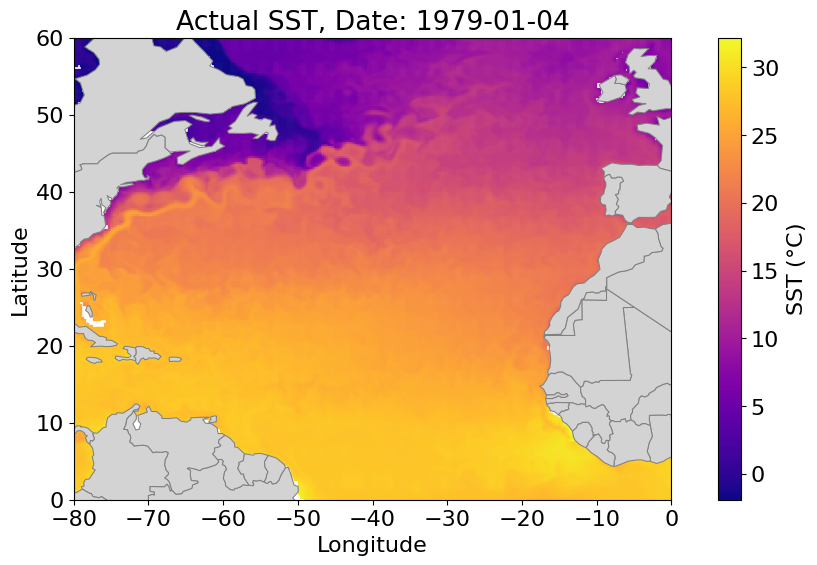

In [51]:
print("Preprocessing data...")
train_data, val_data, test_data, train_dates, val_dates, test_dates = split_ordered_data(data, dates, all_dates=True)

# Plots for santity checks:
plot_index = 0
sst_df = pd.DataFrame({
    "Longitude": longs,
    "Latitude": lats,
    "SST": train_data[plot_index]
})
if dataset == "NOAA":
    ms = 25
else:
    ms = 1
plot_sst_map(sst_df, cmap="plasma", title=f"Actual SST, Date: {train_dates[plot_index]}", area=area, marker_size=ms)

In [52]:
if anomaly:
    train_data, val_data, test_data, bulk_mean = convert_to_anomaly((train_data, val_data, test_data))
    anomaly_df = pd.DataFrame({
            "Longitude": longs,
            "Latitude": lats,
            "SST": train_data[plot_index]
        })
    plot_sst_map(anomaly_df, cmap="viridis", title=f"SST Anomaly, Date: {train_dates[plot_index]}", area=area)

    bulk_df = pd.DataFrame({
        "Longitude": longs,
        "Latitude": lats,
        "SST": bulk_mean
    })
    plot_sst_map(bulk_df, cmap="plasma", title=f"Bulk mean SST, Dates: {train_dates[0]} to {train_dates[-1]}", area=area)

In [53]:
print("Training shape:\t\t", train_data.shape)
print("Validation shape:\t", val_data.shape)
print("Test shape:\t\t", test_data.shape)
print("Total number of time samples:\t", len(train_data)+len(test_data)+len(val_data))

Training shape:		 (1408, 59063)
Validation shape:	 (235, 59063)
Test shape:		 (235, 59063)
Total number of time samples:	 1878


In [54]:
if sensor_placement == "random":
    # Set sensor locations
    sensor_locations = np.random.choice(data.shape[1], size=num_sensors, replace=False)
    sensor_coords=(longs[sensor_locations], lats[sensor_locations])
    print(f"Sensor location indexes will be: {sensor_locations}")

    # Set POD basis
    U_r = svd_basis(train_data, num_sensors)

elif sensor_placement == "QR":
    sensor_locations, U_r = qr_place(train_data, num_sensors)
    sensor_coords=(longs[sensor_locations], lats[sensor_locations])
    print(f"Sensor location indexes will be: {sensor_locations}")

else:
    raise ValueError("Incorrect placement of sensors specified")

Sensor location indexes will be: [37151 32265 58369 35910 15466 12491 53825 12199 51842  1827  8659 57943
 10181 39266 38719 31101 26867  9923 40281 31121 23646  9165 40105 25795
 38809 27071 30026 20172 44470 53710 51592 12765  5635 24670 38193 34382
 55893 34267 21465  2139 56028  9559 36082 44965 20084 20223  4428  2306
 30884 28727 49470 55527 55351 35341 24915 53021 26749 58294 11001 13383
 33239 48986 46419 55960 41773 56987  9732 53006 33410 27061 40745 15723
 57846 28164 28842 50370 41239 41521  4380 27335 41209 49099 52927 39160
 46289  3442 27682 16139 51656 42105 31850 52176  9941  6459 38106 39318
  2494  8299 29202 48068]


In [55]:
# Generate test set to match SHRED test set
# (use final sensor results for what each sequence would be if using SHRED)
test_input, ground_truth = create_pod_test_data(test_data, sensor_locations, test_lags=lags)
test_lag_dates = test_dates[np.array(range(len(test_dates)-lags)) + lags - 1]

In [56]:
print(test_input.shape)
print(ground_truth.shape)

(183, 100)
(183, 59063)


## Generate POD reconstructions

In [57]:
C = np.zeros((num_sensors, len(lats)))
for i in range(num_sensors):
    C[i, sensor_locations[i]] = 1

A = C @ U_r

cond = np.linalg.cond(A)
if cond > 1e10:
    print(f"Warning: C @ U_r is ill-conditioned (cond={cond:.2e}) "
          f"for placement='{sensor_placement}'.")

coeffs, *_ = np.linalg.lstsq(A, test_input.T, rcond=None)
test_recons = (U_r @ coeffs).T

POD: Lag index: 0
-107.58737446696783 153.14080636314407


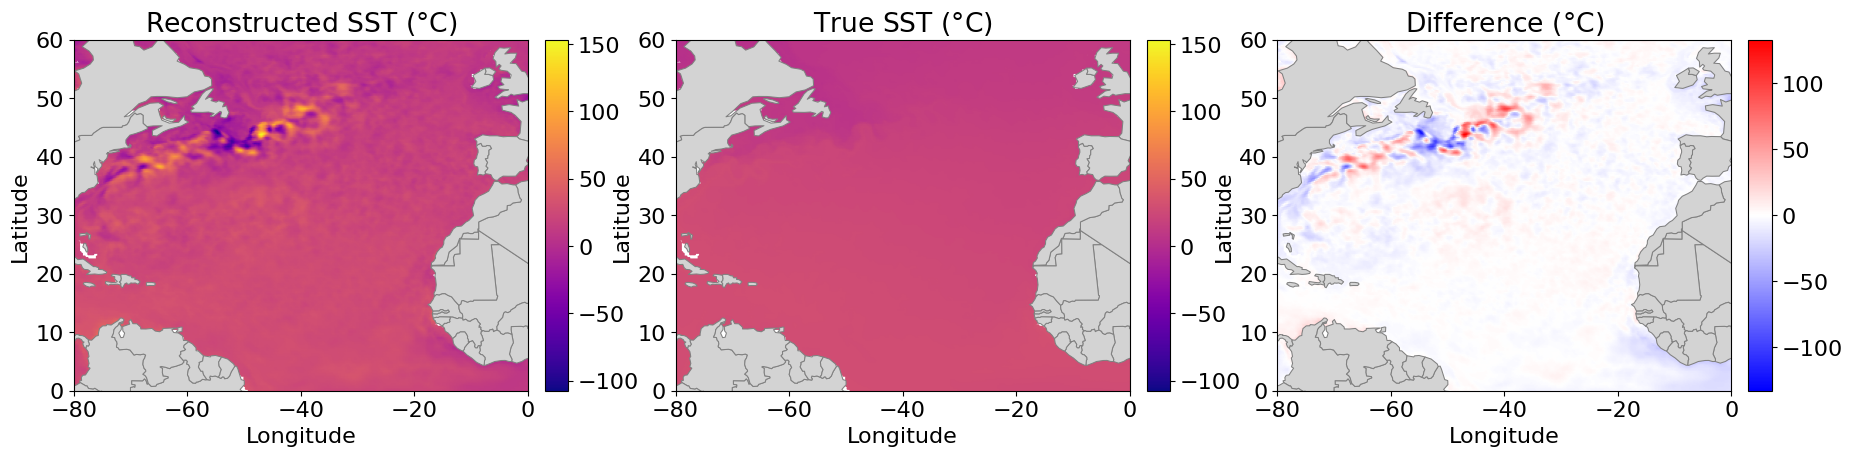

In [ ]:
# Check reconstruction visually
i = 0
difference = test_recons - ground_truth

diff_df = pd.DataFrame({
    "Latitude": lats,
    "Longitude": longs,
    "SST": difference[i]
})
recon_df = pd.DataFrame({
    "Latitude": lats,
    "Longitude": longs,
    "SST": test_recons[i]
})
true_df = pd.DataFrame({
    "Latitude": lats,
    "Longitude": longs,
    "SST": ground_truth[i]
})
# plot_sst_map(diff_df, title=f"Difference map for {test_dates[i]}", min_sst=-5, max_sst=5, area="NA", cmap='bwr')
print(f"POD: Lag index: {i}")
print(min(recon_df.SST), max(recon_df.SST))

if dataset == "NOAA":
    marker_size = 25
else:
    marker_size = 1
# plot_sst_map(recon_df, area="NA", marker_size=marker_size)
plot_compare_sst_recon(recon_df, true_df, diff_data=diff_df, area=area, marker_size=marker_size)  #, sensor_coords=sensor_coords)

## Save POD results

In [ ]:
# Make experiment folder
directory = f"Reconstructions/Static/{pod_name}/"
os.makedirs(directory, exist_ok = True)

In [ ]:
np.save(f"Reconstructions/Static/{pod_name}/recons_n{num_sensors}_l{lags}", test_recons)
np.save(f"Reconstructions/Static/{pod_name}/truth_n{num_sensors}_l{lags}", ground_truth)

In [ ]:
metadata = {
    "sensor_locations": list(sensor_locations),
    "sensor_coords": list(sensor_coords),
    "test_lag_dates": list(test_lag_dates)
    }

if anomaly:
    metadata["bulk_mean"] = bulk_mean
with open(f"Reconstructions/Static/{pod_name}/metadata_n{num_sensors}_l{lags}.json", 'w', encoding='utf-8') as f:
    json.dump(metadata, f, cls=JsonEncoder)

## Scipy interpolation

In [ ]:
points = np.array([[sensor_coords[0][i], sensor_coords[1][i]] for i in range(len(sensor_coords[0]))])
full_coords = np.column_stack([longs, lats])

In [ ]:
print(points.shape)
print(full_coords.shape)

In [ ]:
rbf_recons = np.zeros((len(test_input), len(lats)))
for j, data in enumerate(test_input):
    interpolator = RBFInterpolator(
        points,
        data,
        kernel='thin_plate_spline',
        smoothing=0.0,      # raise this (e.g. 1e-2–1e0) if sensors are noisy
    )
    rbf_recons[j] = interpolator(full_coords)

In [ ]:
print(test_input.shape)
print(ground_truth.shape)
print(rbf_recons.shape)

In [ ]:
df = pd.DataFrame({
        "Latitude": lats,
        "Longitude": longs,
        "SST": rbf_recons[3]
    })
plot_sst_map(df, area="NA", sensor_coords=sensor_coords, marker_size=15)

In [ ]:
directory = f"Reconstructions/Static/{rbfi_name}/"
os.makedirs(directory, exist_ok = True)
np.save(f"Reconstructions/Static/{rbfi_name}/recons_n{num_sensors}_l{lags}", rbf_recons)
np.save(f"Reconstructions/Static/{rbfi_name}/truth_n{num_sensors}_l{lags}", ground_truth)

In [ ]:
metadata = {
    "sensor_locations": list(sensor_locations),
    "sensor_coords": list(sensor_coords),
    "test_lag_dates": list(test_lag_dates)
    }

if anomaly:
    metadata["bulk_mean"] = bulk_mean
with open(f"Reconstructions/Static/{rbfi_name}/metadata_n{num_sensors}_l{lags}.json", 'w', encoding='utf-8') as f:
    json.dump(metadata, f, cls=JsonEncoder)

## References
[[1]](https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html) NOAA dataset origin, https://psl.noaa.gov/data/gridded/data.noaa.oisst.v2.html

[[2]](https://github.com/Jan-Williams/pyshred/blob/main/Data/SST_data.mat) Jan P Williams, pyshred repository, NOAA SST dataset, https://github.com/Jan-Williams/pyshred/blob/main/Data/SST_data.mat

[[3]](https://data.csiro.au/collection/csiro%3A60826v9) CSIRO ME4OH OFAM3 dataset, v9, https://data.csiro.au/collection/csiro%3A60826v9

[[4]](https://github.com/Jan-Williams/pyshred/blob/main/processdata.py) Jan P Williams, pyshred repository, POD implementation, https://github.com/Jan-Williams/pyshred/blob/main/processdata.py